# Mappeoppgave - Del 2.2, IIRA2001 - Høst 2023

# Aldersfordeling etter kommuner

### Hvor bosetter ulike aldersgrupper seg? 

Er det slik at den unge befolkningen generelt flytter til storbyer, og det er kun gamle folk igjen på bygda? Er det utdanning og jobb som tiltrekker de unge, eller storbyen i seg selv?

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

befolkning_alder_df = pd.read_csv("07459_20231212-183048.csv", sep = ";", encoding = "UTF-8", header = 4, index_col = [0])

befolkning_alder_df.index.name = 'Kommune'

befolkning_alder_df.index = befolkning_alder_df.index.str.split(n=1).str[1]

befolkning_alder_df = befolkning_alder_df.drop(befolkning_alder_df.index[356:543])

befolkning_alder_df



,0-4 år,5-9 år,10-14 år,15-19 år,20-24 år,25-29 år,30-34 år,35-39 år,40-44 år,45-49 år,...,55-59 år,60-64 år,65-69 år,70-74 år,75-79 år,80-84 år,85-89 år,90-94 år,95-99 år,100 år eller eldre
Kommune,,,,,,,,,,,,,,,,,,,,,
Halden,1332.0,1674.0,1888.0,1897.0,1812.0,1871.0,2002.0,1885.0,1925.0,2056.0,...,2232.0,2034.0,1922.0,1719.0,1581.0,818.0,473.0,243.0,67.0,11.0
Moss,2348.0,2672.0,3014.0,3056.0,2730.0,2883.0,3119.0,3180.0,3225.0,3484.0,...,3730.0,3201.0,2869.0,2764.0,2474.0,1363.0,784.0,337.0,90.0,14.0
Sarpsborg,2921.0,3320.0,3712.0,3573.0,3372.0,3648.0,3993.0,3658.0,3762.0,3987.0,...,3855.0,3500.0,3190.0,2815.0,2685.0,1461.0,802.0,373.0,93.0,6.0
Fredrikstad,3802.0,4469.0,4975.0,5220.0,4880.0,5001.0,5415.0,5288.0,5049.0,5538.0,...,6036.0,5357.0,4951.0,4271.0,3809.0,2125.0,1241.0,547.0,105.0,6.0
Drammen,5060.0,5672.0,6184.0,6430.0,5758.0,6505.0,7335.0,7280.0,7076.0,7249.0,...,6547.0,5778.0,5197.0,4539.0,4451.0,2442.0,1409.0,618.0,167.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Berlevåg,37.0,29.0,26.0,39.0,41.0,79.0,60.0,50.0,44.0,46.0,...,89.0,69.0,65.0,61.0,54.0,29.0,12.0,10.0,2.0,0.0
Deatnu - Tana,130.0,114.0,139.0,132.0,167.0,137.0,173.0,138.0,152.0,204.0,...,210.0,170.0,192.0,194.0,147.0,95.0,42.0,18.0,4.0,1.0
Unjárga - Nesseby,28.0,29.0,62.0,27.0,40.0,47.0,42.0,58.0,47.0,48.0,...,57.0,59.0,59.0,73.0,53.0,37.0,23.0,6.0,2.0,1.0


Nedenfor viser jeg et eksempel på hvordan finne antall personer over 100 år i Ålesund.

In [140]:
befolkning_alder_df.loc["Ålesund"]["100 år eller eldre"]

13.0

For eksempel kan vi vise aldersfordelingen i en kommune ved kakediagram. Her har jeg valgt Trondheim.

Oppdaget her at Trondheim også benevnes på sørsamisk. Endrer dette til kun Trondheim.

In [141]:
befolkning_alder_df.iloc[238]

0-4 år                10614.0
5-9 år                11256.0
10-14 år              11818.0
15-19 år              11672.0
20-24 år              18776.0
25-29 år              19886.0
30-34 år              18081.0
35-39 år              15079.0
40-44 år              13864.0
45-49 år              13175.0
50-54 år              13264.0
55-59 år              12161.0
60-64 år              10429.0
65-69 år               9613.0
70-74 år               8321.0
75-79 år               7054.0
80-84 år               4054.0
85-89 år               2155.0
90-94 år               1060.0
95-99 år                300.0
100 år eller eldre       28.0
Name: Trondheim - Tråante, dtype: float64

In [142]:
befolkning_alder_df = befolkning_alder_df.rename(index={"Trondheim - Tråante": "Trondheim"})

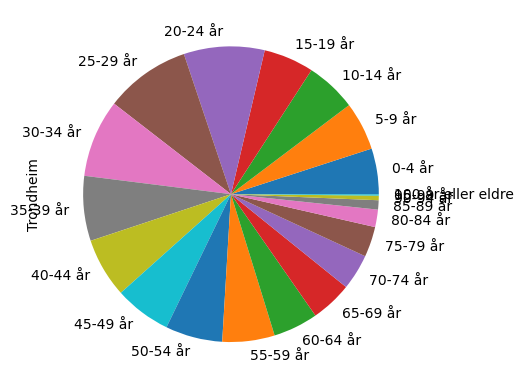

In [143]:
aldersfordeling_trondheim = befolkning_alder_df.loc['Trondheim', :]

plot = aldersfordeling_trondheim.plot.pie()

Ser en ganske jevn og forventet fordeling. Innser her at de korte intervallene ikke er helt relevant, og slår derfor sammen 4 og 4 kollonner og lager et nytt dataframe.

In [144]:
kollonne1 = befolkning_alder_df.iloc[:, 0:4]
kollonne2 = befolkning_alder_df.iloc[:, 4:8]
kollonne3 = befolkning_alder_df.iloc[:, 8:12]
kollonne4 = befolkning_alder_df.iloc[:, 12:16]
kollonne5 = befolkning_alder_df.iloc[:, 16:21]

aldersfordeling_df = pd.DataFrame({
    '0-19 år': kollonne1.sum(axis=1),
    '20-39 år': kollonne2.sum(axis=1),
    '40-59 år': kollonne3.sum(axis=1),
    '50-69 år': kollonne4.sum(axis=1),
    '70-100 år': kollonne5.sum(axis=1)
})

aldersfordeling_df['Kommune'] = befolkning_alder_df.index

aldersfordeling_df.set_index('Kommune', inplace = True)

aldersfordeling_df

,0-19 år,20-39 år,40-59 år,50-69 år,70-100 år
Kommune,,,,,
Halden,6791.0,7570.0,8501.0,7256.0,1612.0
Moss,11090.0,11912.0,14342.0,11308.0,2588.0
Sarpsborg,13526.0,14671.0,15916.0,12190.0,2735.0
Fredrikstad,18466.0,20584.0,22982.0,18388.0,4024.0
Drammen,23346.0,26878.0,28446.0,19965.0,4656.0
...,...,...,...,...,...
Berlevåg,131.0,230.0,245.0,249.0,53.0
Deatnu - Tana,515.0,615.0,811.0,703.0,160.0
Unjárga - Nesseby,146.0,187.0,218.0,244.0,69.0


Nytt kakediagram for Tronhdeim med nytt DF. Sammenligner med kakediagram for en liten kommune, herved Hattfjelldal.

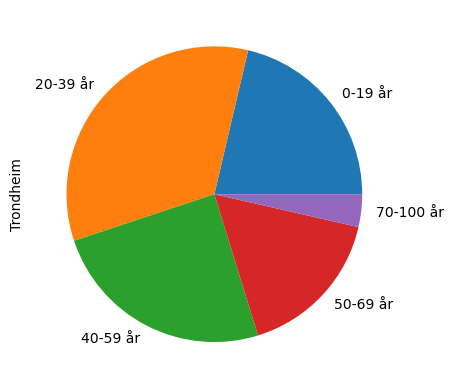

In [145]:
aldersfordeling_trondheim2 = aldersfordeling_df.loc['Trondheim', :]

plot = aldersfordeling_trondheim2.plot.pie()

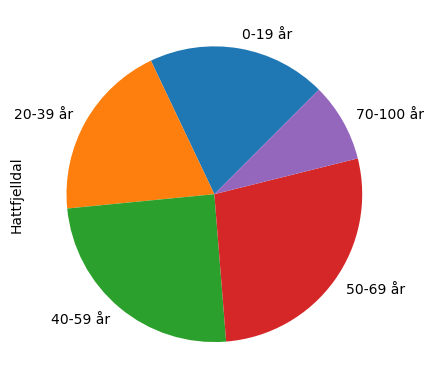

In [146]:
aldersfordeling_hattfjelldal = aldersfordeling_df.loc['Hattfjelldal', :]

plot = aldersfordeling_hattfjelldal.plot.pie(startangle = 45)

Ser stor forskjell i den typiske studentgruppen og unge arbeidstakere 20-39 år, som forventet. Mange små og gjerne desentraliserte kommuner sliter med høy fraflytting og en eldrebølge. Ønsker videre å finne en trend i hele Norge for hvor ulike aldersgrupper bosetter seg. Det er godt kjent at unge ofte må flytte fra sin hjemkommune for å studere og finne jobb, men i hvor stor grad basert på disse innbyggerdataene? 

Deler inn kommuner i 4 grupper, små-, mellomsmå-, mellomstore- og store kommuner. Lager nytt DF med en 6. kollonne for totalt innbyggertall, dette for oversiktlighet, og å enkelt dele inn kommunene i grupper basert på innbyggertall.

In [147]:
kollonne6 = aldersfordeling_df.iloc[:, 0:5]

alderdata_df = pd.DataFrame({
    '0-19 år': kollonne1.sum(axis=1),
    '20-39 år': kollonne2.sum(axis=1),
    '40-59 år': kollonne3.sum(axis=1),
    '50-69 år': kollonne4.sum(axis=1),
    '70-100 år': kollonne5.sum(axis=1),
    'Innbyggere': kollonne6.sum(axis=1)
})

alderdata_df['Kommune'] = aldersfordeling_df.index

alderdata_df.set_index('Kommune', inplace = True)

alderdata_df

,0-19 år,20-39 år,40-59 år,50-69 år,70-100 år,Innbyggere
Kommune,,,,,,
Halden,6791.0,7570.0,8501.0,7256.0,1612.0,31730.0
Moss,11090.0,11912.0,14342.0,11308.0,2588.0,51240.0
Sarpsborg,13526.0,14671.0,15916.0,12190.0,2735.0,59038.0
Fredrikstad,18466.0,20584.0,22982.0,18388.0,4024.0,84444.0
Drammen,23346.0,26878.0,28446.0,19965.0,4656.0,103291.0
...,...,...,...,...,...,...
Berlevåg,131.0,230.0,245.0,249.0,53.0,908.0
Deatnu - Tana,515.0,615.0,811.0,703.0,160.0,2804.0
Unjárga - Nesseby,146.0,187.0,218.0,244.0,69.0,864.0


In [148]:
småkommuner_df = alderdata_df.query('Innbyggere<3000')
mellomsmå_kommuner_df = alderdata_df.query('(Innbyggere>=3000) & (Innbyggere<10000)')
mellomstore_kommuner_df = alderdata_df.query('(Innbyggere<100000) & (Innbyggere>=10000)')
store_kommuner_df = alderdata_df.query('Innbyggere>=100000')

Beregner gjennomsnitt for de ulike aldersgruppene i de 4 kommuneinndelingene, for å sammenligne aldersfordelingen mellom små, mellomsmå, mellomstore og store kommuner.

In [149]:
aldersnitt_småkommuner = småkommuner_df.mean()
aldersnitt_mellomsmå_kommuner = mellomsmå_kommuner_df.mean()
aldersnitt_mellomstore_kommuner = mellomstore_kommuner_df.mean()
aldersnitt_store_kommuner = store_kommuner_df.mean()

alderfordeling_snitt_df = pd.DataFrame({
    'Små kommuner': aldersnitt_småkommuner,
    'Mellomsmå kommuner': aldersnitt_mellomsmå_kommuner,
    'Mellomstore kommuner': aldersnitt_mellomstore_kommuner,
    'Store kommuner': aldersnitt_store_kommuner
})

alderfordeling_snitt_df = alderfordeling_snitt_df.T

del alderfordeling_snitt_df['Innbyggere']

alderfordeling_snitt_df


,0-19 år,20-39 år,40-59 år,50-69 år,70-100 år
Små kommuner,355.138462,370.100000,452.123077,454.669231,114.723077
Mellomsmå kommuner,1293.226087,1324.034783,1542.617391,1375.504348,330.226087
Mellomstore kommuner,6486.846154,6884.125000,7462.740385,5620.000000,1253.875000
Store kommuner,53129.428571,78736.571429,62888.285714,39917.857143,9009.571429


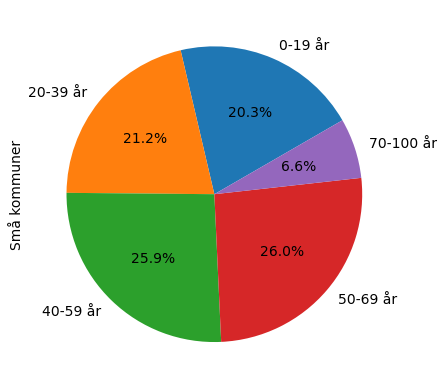

In [150]:
fordeling_små = alderfordeling_snitt_df.loc['Små kommuner']
fordeling_mellomsmå = alderfordeling_snitt_df.loc['Mellomsmå kommuner']
fordeling_mellomstore = alderfordeling_snitt_df.loc['Mellomstore kommuner']
fordeling_store = alderfordeling_snitt_df.loc['Store kommuner']

plot = fordeling_små.plot.pie(autopct='%1.1f%%', startangle = 30)

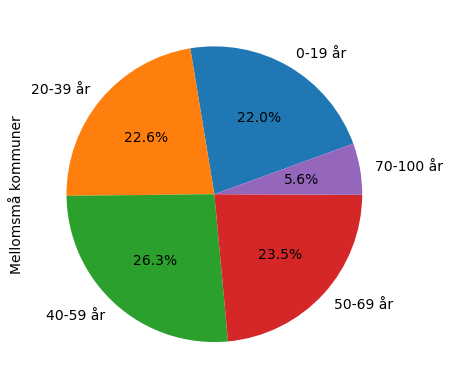

In [151]:
plot = fordeling_mellomsmå.plot.pie(autopct='%1.1f%%', startangle = 20)

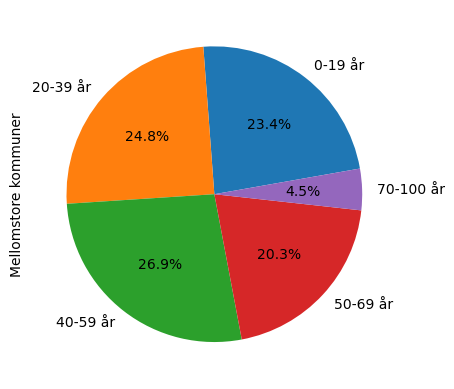

In [152]:
plot = fordeling_mellomstore.plot.pie(autopct='%1.1f%%', startangle = 10)

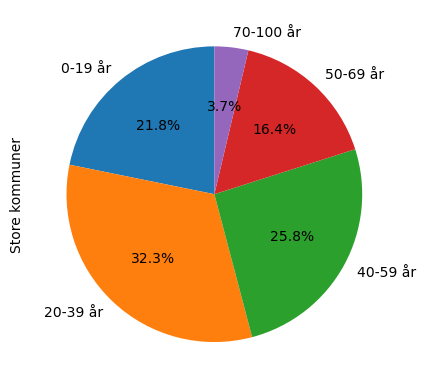

In [153]:
plot = fordeling_store.plot.pie(autopct='%1.1f%%', startangle = 90)

Basert på de 4 kakediagrammene ovenfor kan vi hente mye interessant informasjon. Aldersintervallet 0-19 år er relativt jevnt, som forventet. Da det er vanlig å bo i fødekommunen frem til man for eksempel skal ut å studere, eller i det minste er blitt voksen. Alderintervallet 20-39 år var for meg noe mer interessant. Jeg hadde på forhånd her forventet et større skille mellom små og mellomstore kommuner. Men vi ser av diagrammer at det ikke er det helt store skillet i denne aldersgruppen mellom små, mellomsmå og mellomstore kommuner. I de store kommuner er imidlertid prosentandelen i aldersintervallet mye høyere enn i de andre. Aldersintervallet 40-59 er jevnt, det er i de høyere verdier at forskjellene i yngre grupper tas igjen i de mindre kommuner. Andelen pensjonister er altså nesten dobbelt så stor i små kommuner, i forhold til i store kommuner. Samt økende antall personer i aldersintervall 50-69 år etterhvert som kommunene blir mindre. Unge voksne trekker til store kommuner, og den eldre garde trives på landet. "Medianbefolkningen" er fleksible, og de yngste har som oftest ingen valg.

Studenter har stor påvirkning på aldersfordelingen rundt om. Ønsker derfor å sammenligne studentbyene Trondheim og Bergen, med de resterende topp 5 største kommuner. Oslo som hovedstad blir her ikke benyttet, da en hovedstad vil ha mange ulike påvirkninger, eller etter all sannsynlighet i det minste flere påvirkninger som er vanskelig å avgrense og spesifisere. Altså vil jeg nå sammenligne Trondheim og Bergen, med Stavanger, Bærum og Kristiansand. Dersom dette gir stor differanse, kan vi se at det ikke nødvendigvis bare er store kommuner i seg selv som trekker til seg unge voksne, men for eksempel Bergen og Trondheim for sine mange skoler og sitt store studentmiljø, blant annet. Men igjen er dette de aller største byene, slik at fasiliteter(skoler i dette tilfellet) ofte henger sammen med størrelse, og arbeidsplasser vil det ofte være flest av der det finnes mest folk.

In [154]:
største_6_kommuner = alderdata_df.nlargest(6, 'Innbyggere')
print(største_6_kommuner)

               0-19 år  20-39 år  40-59 år  50-69 år  70-100 år  Innbyggere
Kommune                                                                    
Oslo          145992.0  258141.0  179903.0  102899.0    22102.0    709037.0
Bergen         62011.0   90930.0   73587.0   50229.0    12573.0    289330.0
Trondheim      45360.0   71822.0   52464.0   35417.0     7597.0    212660.0
Stavanger      34781.0   41190.0   39314.0   25510.0     5216.0    146011.0
Bærum          32844.0   29262.0   36790.0   24755.0     6223.0    129874.0
Kristiansand   27572.0   32933.0   29714.0   20650.0     4700.0    115569.0


In [155]:
studentbyer_df = alderdata_df.loc[['Trondheim', 'Bergen'], :]
studentbyer_df.drop('Innbyggere', axis=1, inplace = True)
studentbyer_df.loc['Studentbyer'] = studentbyer_df.sum()

store_byer_df = alderdata_df.loc[['Stavanger', 'Bærum', 'Kristiansand'], :]
store_byer_df.drop('Innbyggere', axis=1, inplace = True)
store_byer_df.loc['Store byer'] = store_byer_df.sum()

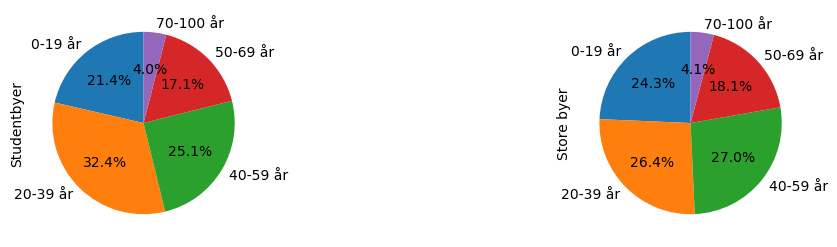

In [156]:
aldersfordeling_studentbyer = studentbyer_df.loc['Studentbyer']
plt.subplot(1, 3, 1)
plot = aldersfordeling_studentbyer.plot.pie(startangle = 90, autopct = '%1.1f%%', figsize = (10, 5))

aldersfordeling_store_byer = store_byer_df.loc['Store byer']
plt.subplot(1, 3, 3)
plot = aldersfordeling_store_byer.plot.pie(startangle = 90, autopct = '%1.1f%%')

Vi ser altså stor differanse i gruppen 20-39 år, for store kommuner seg imellom. De øvrige gruppene, eks. 0-19 år vil være relativt mindre hvor det er relativt flere studenter, og relativt færre foreldre. Forholdet mellom foreldregruppen og barn/ungdom vil sannsynligvis i stor grad henge sammen.

Eksempelvis Bærum er en kommune med høye boligpriser, og en kommune hvor mange nettopp ønsker å flytte til for å bosette seg i en enebolig på Østlandet. Flere områder i Bærum kan anses som relativt eksklusive, og det vil da generelt være naturlig at dette ikke er de yngste menneskene som har mulighet til å bosette seg her. Basert på de siste diagramene må konklusjonen til en viss grad korrigeres, da vi ser at det ikke er så enkelt som at store kommuner i seg selv tiltrekker unge borgere, men kanskje heller som jeg var inne på, fasilitetene som medfølger. Noe som kan støtte opp om fasiliteter fremfor størrelse, er Gjøvik. Gjøvik er etter mine avgrensinger, en mellomstor kommune. (Dette er et stort intervall, men Gjøvik kun ca 30 000 innbyggere.) I tillegg til Ålesund og Trondheim, har Gjøvik et NTNU Campus. Så selv om dette ikke er en stor kommune, kan aldersfordelingen være helt annerledes. Jeg vil helt til slutt fremstille et kakediagram av aldersfordelingen i Gjøvik for å undersøke dette.

In [157]:
alderdata_df.loc['Gjøvik']

0-19 år        6356.0
20-39 år       7861.0
40-59 år       8017.0
50-69 år       6734.0
70-100 år      1595.0
Innbyggere    30563.0
Name: Gjøvik, dtype: float64

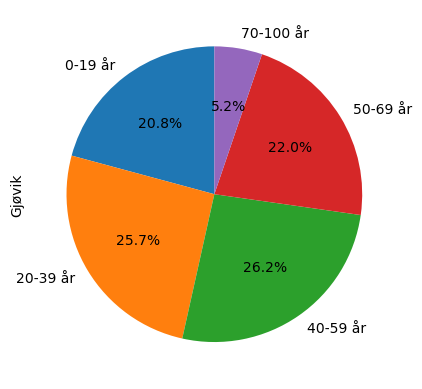

In [158]:
gjøvik_df = alderdata_df.loc['Gjøvik', :]
del gjøvik_df['Innbyggere']
plot = gjøvik_df.plot.pie(autopct='%1.1f%%', startangle = 90)

Gjøvik har en andel på 25.7% for intervallet 20-39 år, gjerne studenter og unge arbeidstakere som tidligere nevnt. 0,9 prosent større enn gjennomsnittet for mellomstore kommuner. Dette ga ikke et like tydelig utfall som forventet, men i gruppen 0-19 år ser vi en differanse på nesten 3%. Det ville her vært interessant å isolert sett sammenligne de ulike gruppene kun i intervallet 20-39 år. Altså hvor mange er studenter, hvor mange er vokst opp der og hvor mange jobber der. Uten å si dette helt sikkert, kan det på et vis se ut som relativt færre barnefamilier, slik at det er en mindre andel barn som vokser opp til å bli unge voksne i kommunen, og at det dermed i svært stor grad er tilflytning av blant annet studenter som holder nivået på intervallet 20-39 år oppe. (Delvis spekulasjon)

In [2]:
import os
print(os.getcwd())

/home/jonajh/fag/IIF-retting/h23/InsperaAssessment_1308938588/10186_155617884_1
